In [2]:
import numpy as np
import astropy.units as u
from astropy.io import fits
from matplotlib.colors import LogNorm
from matplotlib.patches import Rectangle, Circle
from pathlib import Path
from IPython.display import clear_output
from importlib import reload
from scipy.optimize import minimize

import poppy
import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

import warnings
warnings.filterwarnings("ignore")

from aefc_vortex.math_module import xp, xcipy, ensure_np_array
from aefc_vortex import utils
from aefc_vortex.imshows import imshow1, imshow2, imshow3
from aefc_vortex import dm
from aefc_vortex import props
from aefc_vortex import aefc_2dm as aefc
import aefc_vortex.fresnel_2dm_96 as fresnel
import aefc_vortex.fraunhofer_2dm_96 as fraunhofer




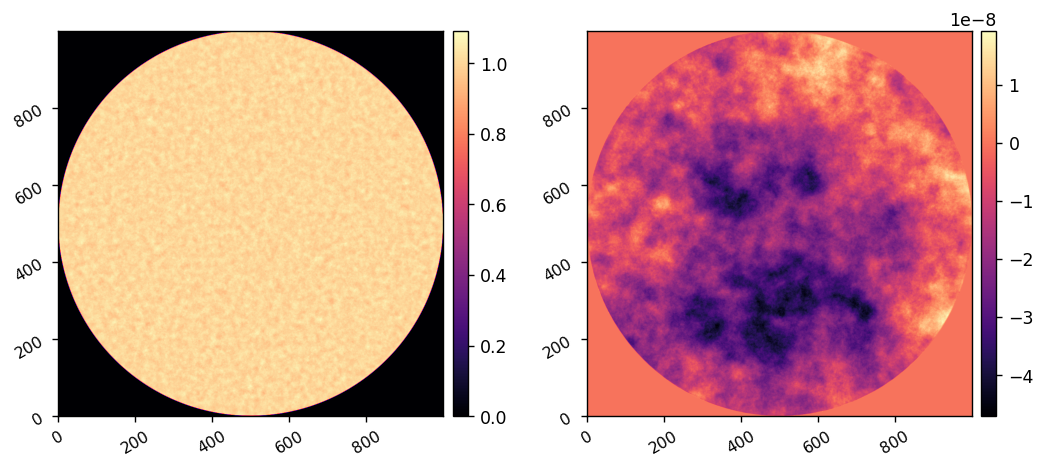

In [3]:
reload(fresnel)
I = fresnel.CORO()
I.use_opds = True

AMP, OPD = I.calc_pupil()
imshow2(AMP, OPD)

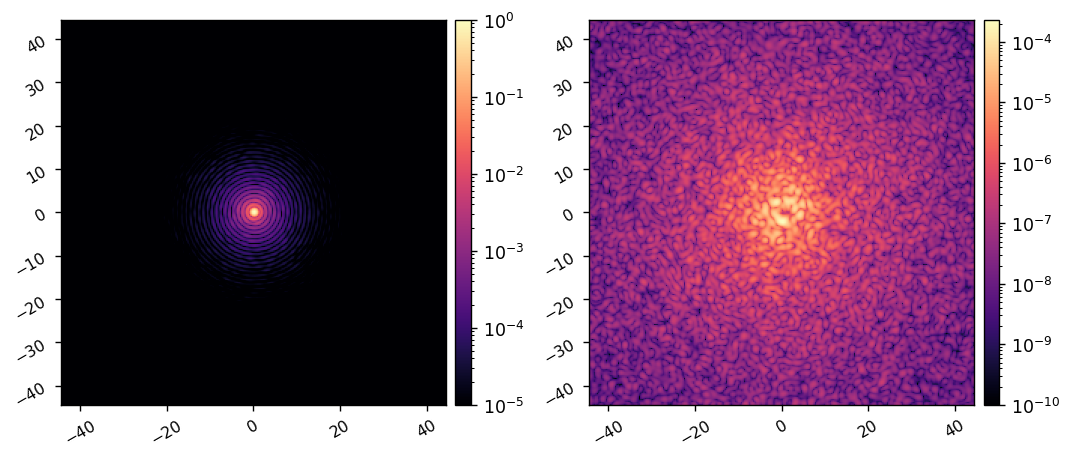

In [4]:
reload(fresnel)
I = fresnel.CORO()
I.use_opds = True

I.use_vortex = False
ref_psf = I.snap()
I.Imax_ref = xp.max(ref_psf)
ref_psf /= I.Imax_ref
I.use_vortex = True
ref_coro_im = I.snap()

imshow2(ref_psf, ref_coro_im,
        pxscl=I.psf_pixelscale_lamDc, lognorm=True, vmin1=1e-5, vmin2=1e-10)


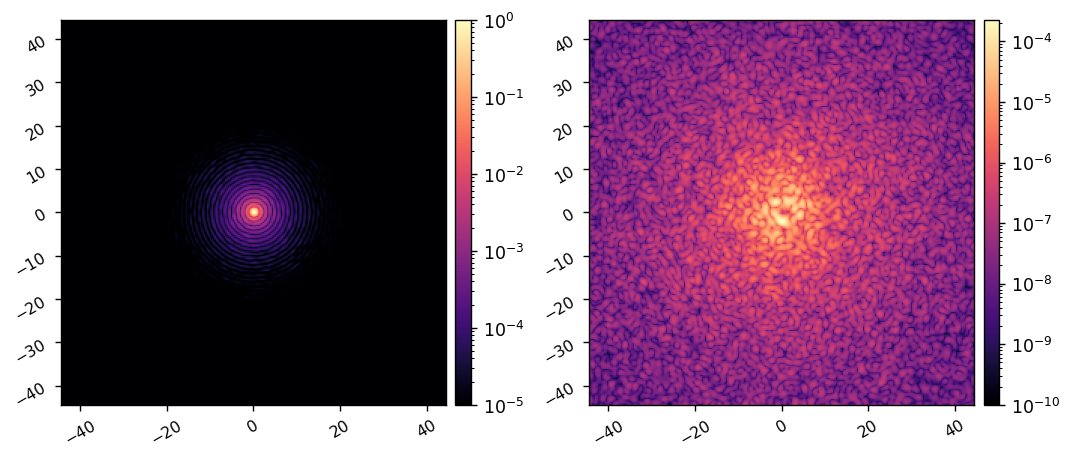

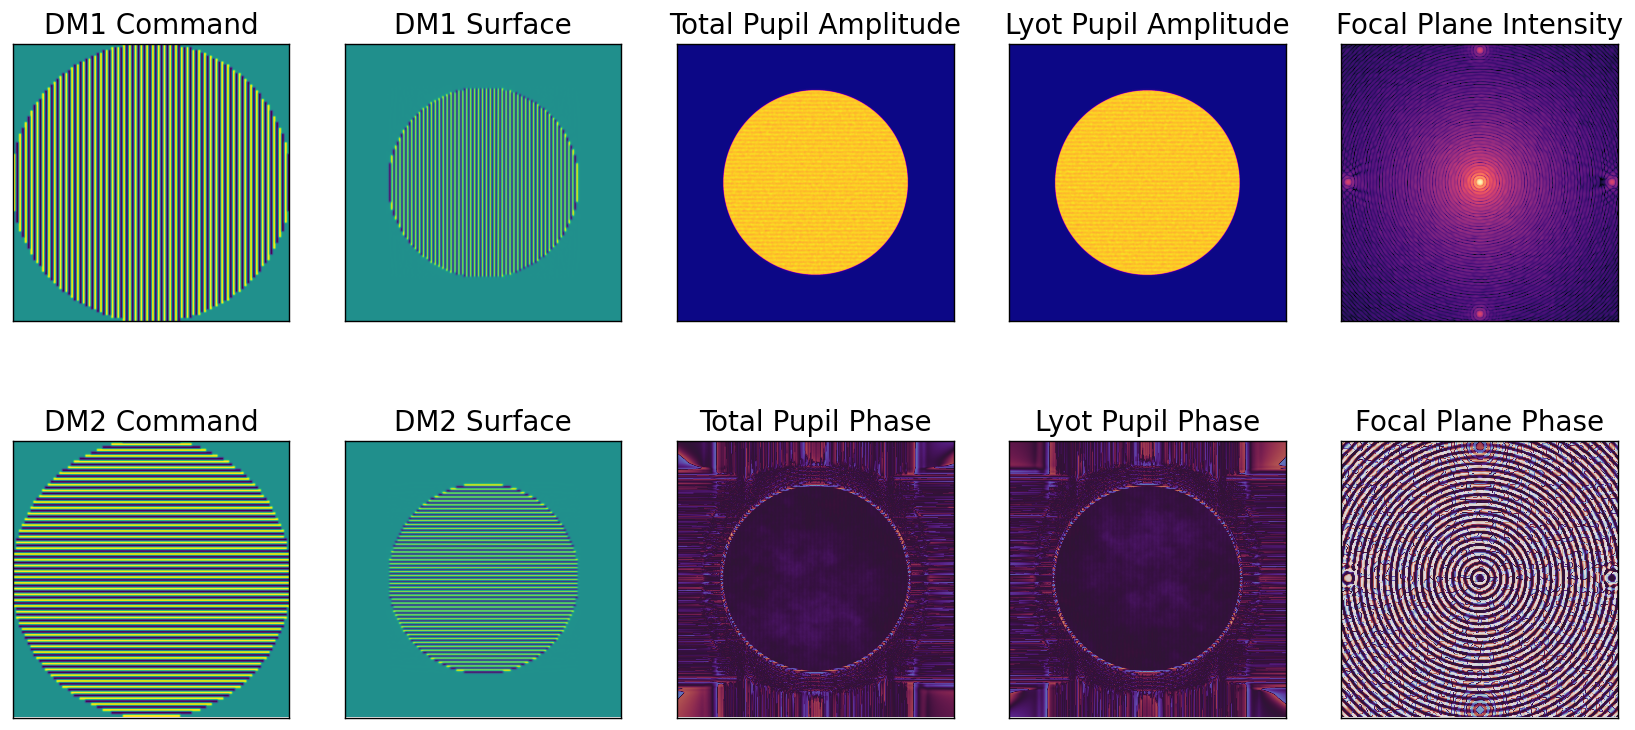

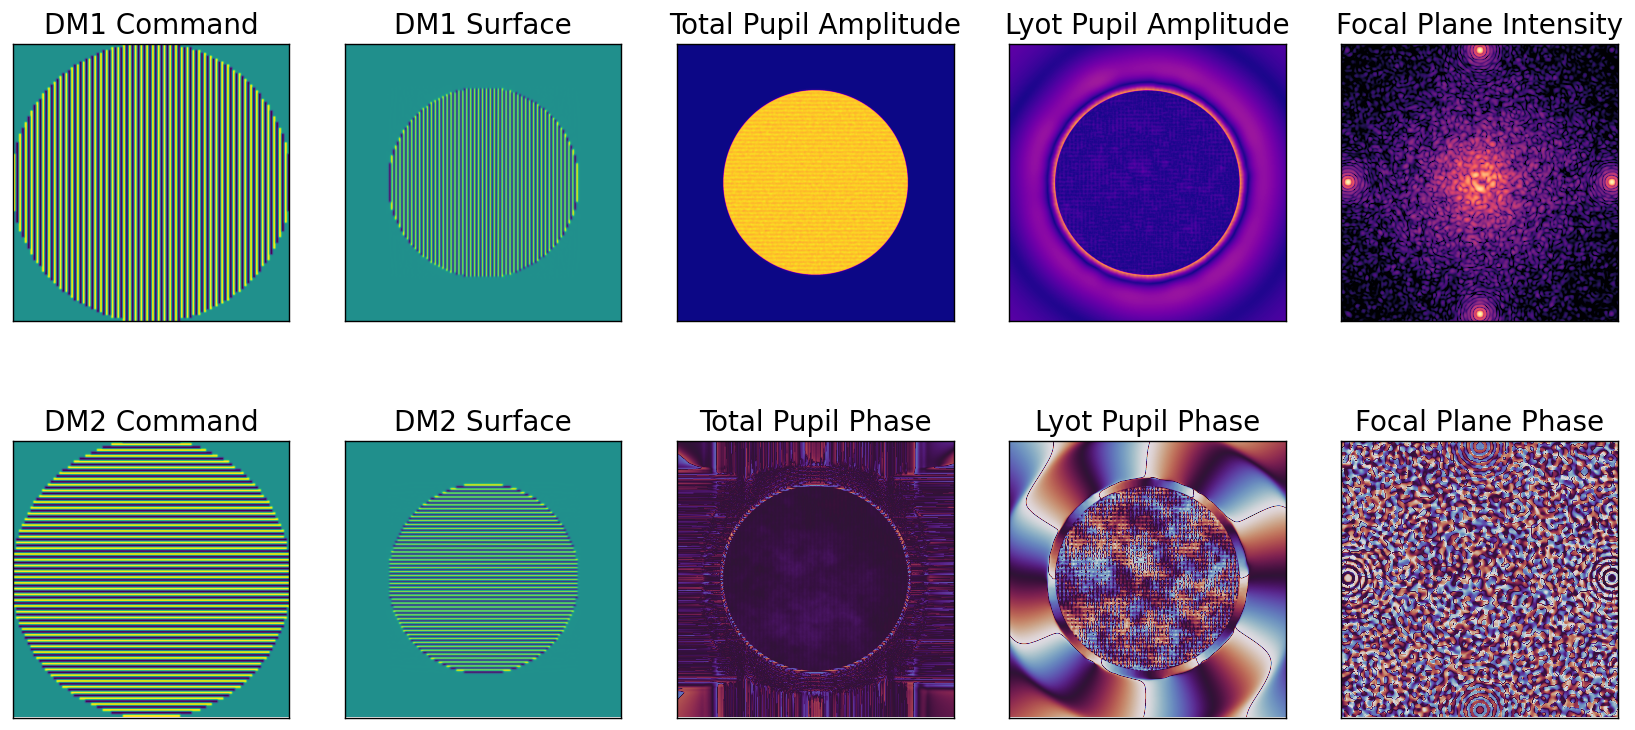

In [5]:
reload(fraunhofer)
M = fraunhofer.MODEL()
M.AMP = AMP
M.OPD = OPD

M.flip_dm = True
M.flip_lyot = True

acts = xp.zeros(M.Nacts)

model_psf = xp.abs( M.forward(acts, M.wavelength_c, use_vortex=0) )**2
M.setattr('Imax_ref', xp.max(model_psf))
model_psf /= M.Imax_ref

model_coro_im = xp.abs( M.forward(acts, M.wavelength_c, use_vortex=1) )**2

imshow2(model_psf, model_coro_im,
        pxscl=M.psf_pixelscale_lamDc, lognorm=True, vmin1=1e-5, vmin2=1e-10)

dm1_command, dm2_command = ( xp.zeros((M.Nact, M.Nact)), xp.zeros((M.Nact, M.Nact)) )
dm1_command = 2.5e-9*utils.make_fourier_command(x_cpa=48, y_cpa=0, Nact=96)
dm2_command = 2.5e-9*utils.make_fourier_command(x_cpa=0, y_cpa=48, Nact=96)

acts = xp.concatenate([dm1_command[M.dm_mask], dm2_command[M.dm_mask]])
fpwf = M.forward(acts, M.wavelength_c, use_vortex=0, fancy_plot=1)
fpwf = M.forward(acts, M.wavelength_c, use_vortex=1, fancy_plot=1)

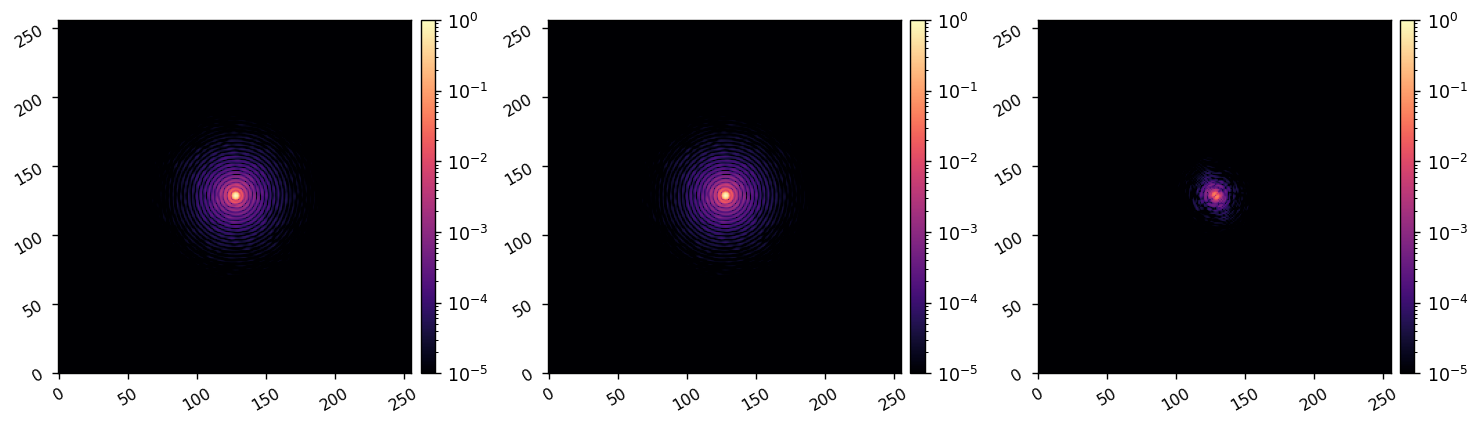

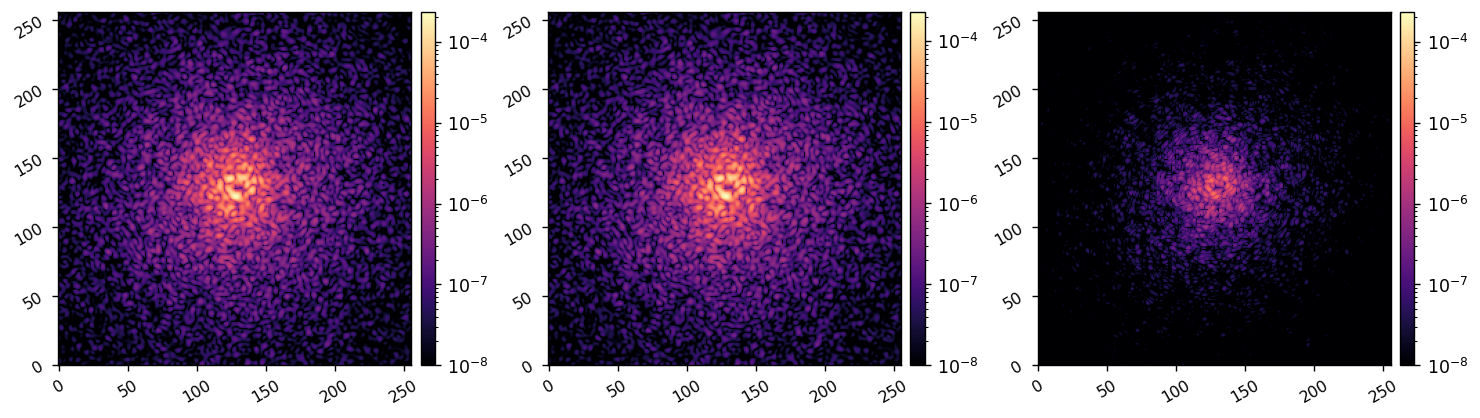

In [6]:
imshow3(ref_psf, model_psf, xp.abs(ref_psf - model_psf), 
        lognorm1=True, lognorm2=True, lognorm3=True, vmax3=1, 
        vmin1=1e-5, vmin2=1e-5, vmin3=1e-5)

imshow3(ref_coro_im, model_coro_im, xp.abs(ref_coro_im - model_coro_im), 
        lognorm1=True, lognorm2=True, lognorm3=True, vmax3=xp.max(ref_coro_im), 
        vmin1=1e-8, vmin2=1e-8, vmin3=1e-8)

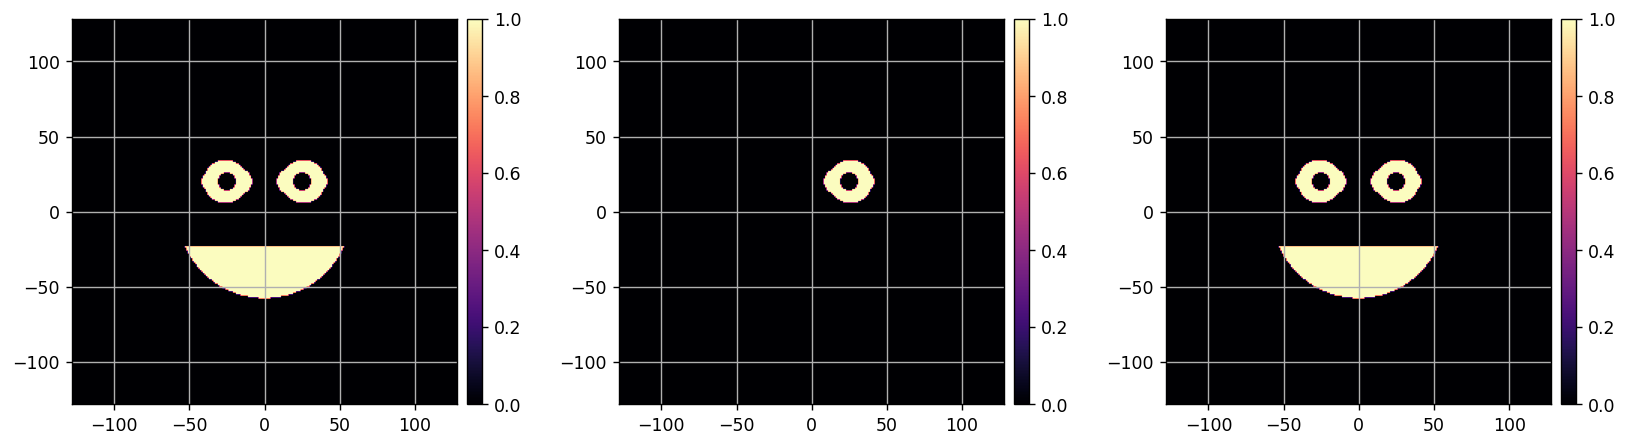

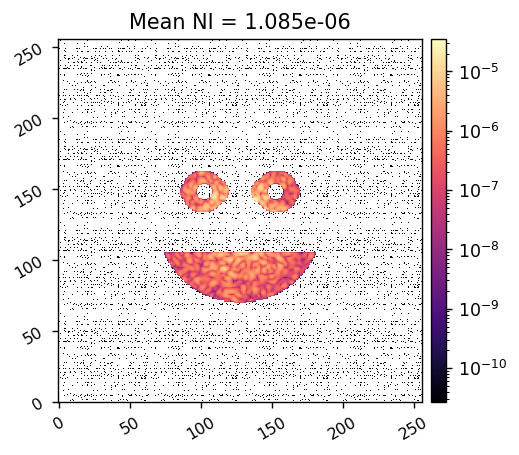

In [39]:
reload(utils)
I.zero_dms()

control_mask_mouth = utils.create_annular_focal_plane_mask(
    I.npsf, I.psf_pixelscale_lamDc, 
    irad=8, 
    orad=20, 
    edge=8, 
    rotation=90,
)

control_mask = control_mask_mouth

for s in [-1, 1]:
    control_mask_eye = utils.create_annular_focal_plane_mask(
        I.npsf, I.psf_pixelscale_lamDc, 
        irad=0, 
        orad=2, 
        edge=None, 
        rotation=0,
        shift=(s*14,20),
    )

    control_mask_eye += utils.create_annular_focal_plane_mask(
        I.npsf, I.psf_pixelscale_lamDc, 
        irad=0, 
        orad=3, 
        edge=None, 
        rotation=0,
        shift=(s*17,20),
    )

    control_mask_eye += utils.create_annular_focal_plane_mask(
        I.npsf, I.psf_pixelscale_lamDc, 
        irad=0, 
        orad=5, 
        edge=None, 
        rotation=0,
        shift=(s*26,20),
    )

    control_mask_eye += utils.create_annular_focal_plane_mask(
        I.npsf, I.psf_pixelscale_lamDc, 
        irad=0, 
        orad=3, 
        edge=None, 
        rotation=0,
        shift=(s*31,20),
    )

    control_mask_eye += utils.create_annular_focal_plane_mask(
        I.npsf, I.psf_pixelscale_lamDc, 
        irad=0, 
        orad=2, 
        edge=None, 
        rotation=0,
        shift=(s*36,20),
    )

    control_mask_eye *= ~utils.create_annular_focal_plane_mask(
        I.npsf, I.psf_pixelscale_lamDc, 
        irad=0, 
        orad=2, 
        edge=None, 
        rotation=0,
        shift=(s*25,20),
    )

    control_mask += control_mask_eye


utils.imshow(
    [control_mask_mouth, control_mask_eye, control_mask],
    pxscls=[1, 1, 1],
    grids=[1, 1, 1],
)

mean_ni = xp.mean(ref_coro_im[control_mask])

imshow1(ref_coro_im*control_mask, f'Mean NI = {mean_ni:.3e}', lognorm=True)

	Cost-function J_delE: 0.004
	Cost-function J_c: 0.000
	Cost-function normalization factor: 0.004
	Total cost-function value: 1.000



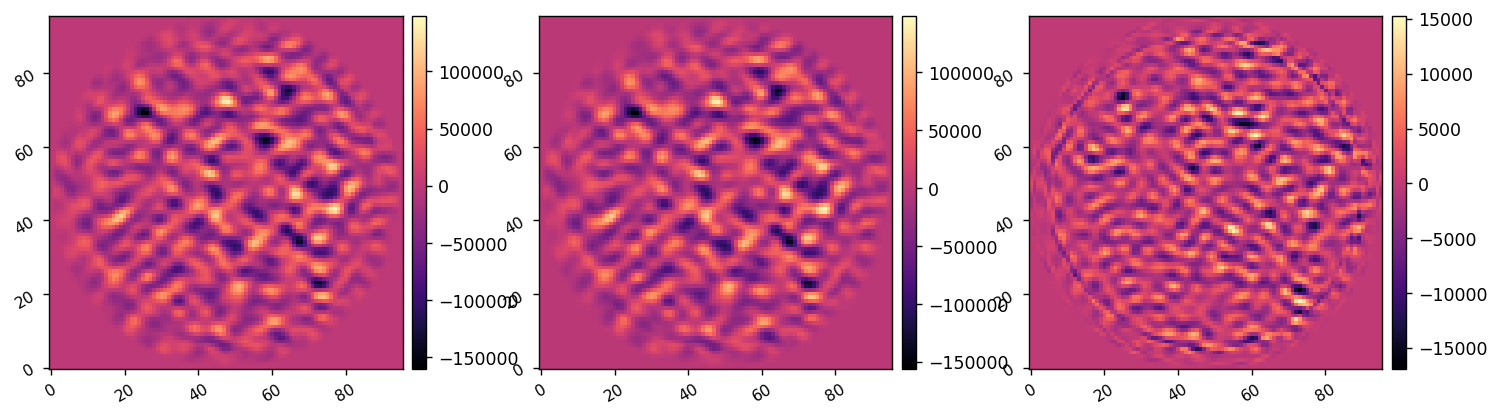

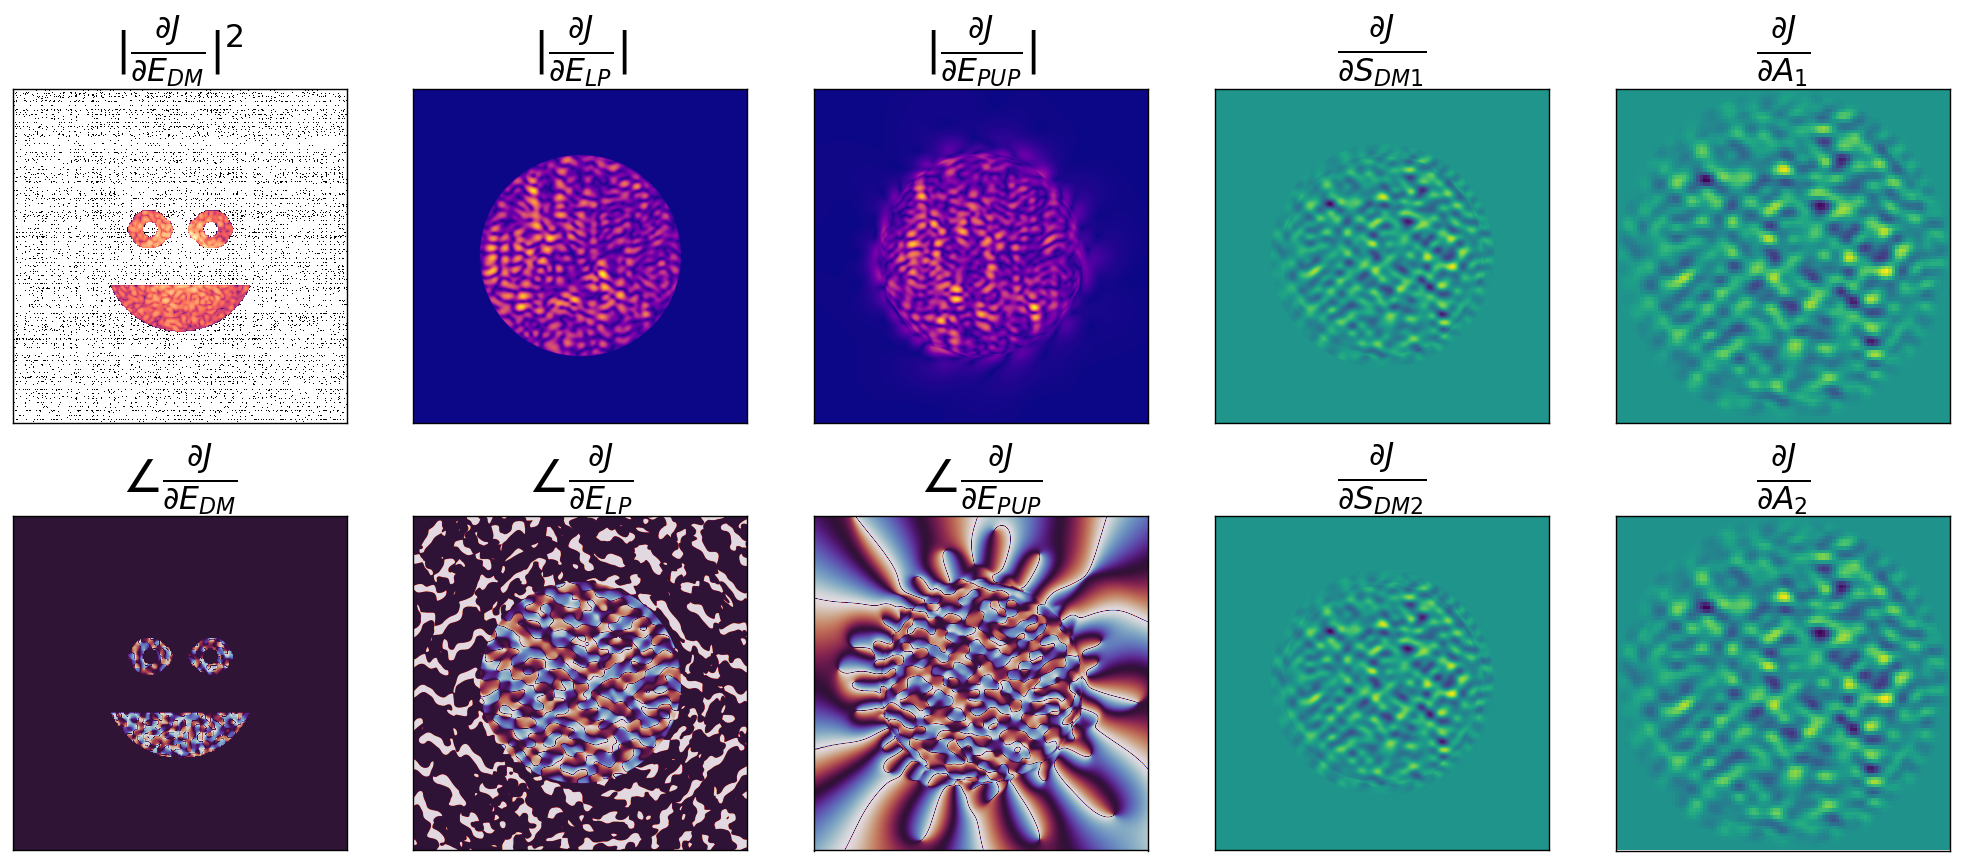

In [26]:
reload(fraunhofer)
current_acts = xp.zeros(M.Nacts)
# current_acts = fits.getdata('example-data/ad_test_acts.fits')

I.set_dm1(fraunhofer.acts_to_command(current_acts[:M.Nacts//2], M.dm_mask))
I.set_dm2(fraunhofer.acts_to_command(current_acts[M.Nacts//2:], M.dm_mask))
E_ab = I.calc_wf() * control_mask

E_FP_NOM = M.forward(current_acts, I.wavelength, use_vortex=True, return_ints=0,)

rmad_vars = { 
    'current_acts':current_acts,
    'E_ab':E_ab, 
    'E_FP_NOM':E_FP_NOM,
    'control_mask':control_mask,
    'wavelength':I.wavelength,
    'r_cond':1e-3,
}

del_acts = np.zeros(M.Nacts)
J, dJ_dA = fraunhofer.val_and_grad(
    del_acts, 
    M, 
    rmad_vars,
    verbose=True, 
    # plot=True, 
    fancy_plot=True,
)

dm1_grad = fraunhofer.acts_to_command(dJ_dA[:M.Nacts//2], M.dm_mask)
dm2_grad = fraunhofer.acts_to_command(dJ_dA[M.Nacts//2:], M.dm_mask)
imshow3(dm1_grad, dm2_grad, dm2_grad-dm1_grad)

In [27]:
reload(fraunhofer)

current_acts = xp.zeros(M.Nacts)
# current_acts = fits.getdata('example-data/ad_test_acts.fits')

I.set_dm1(fraunhofer.acts_to_command(current_acts[:M.Nacts//2], M.dm_mask))
I.set_dm2(fraunhofer.acts_to_command(current_acts[M.Nacts//2:], M.dm_mask))
E_ab = I.calc_wf() * control_mask
E_FP_NOM = M.forward(current_acts, I.wavelength, use_vortex=True, return_ints=0,)

rmad_vars = { 
    'current_acts':current_acts,
    'E_ab':E_ab, 
    'E_FP_NOM':E_FP_NOM,
    'control_mask':control_mask,
    'wavelength':I.wavelength,
    'r_cond':1e-3,
}

bfgs_tol = 1e-3
bfgs_opts = {
    'disp':True,
    # 'maxls':50,
    # 'ftol':1e-6,
    # 'gtol':1e-6,
}

del_acts0 = np.zeros(M.Nacts)
res = minimize(
    fraunhofer.val_and_grad, 
    jac=True, 
    x0=del_acts0,
    args=(M, rmad_vars, True, False), 
    method='L-BFGS-B',
    tol=bfgs_tol,
    options=bfgs_opts,
)


	Cost-function J_delE: 0.004
	Cost-function J_c: 0.000
	Cost-function normalization factor: 0.004
	Total cost-function value: 1.000

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =        14736     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.00000D+00    |proj g|=  1.60450D+05
	Cost-function J_delE: 0.006
	Cost-function J_c: 2366863905.325
	Cost-function normalization factor: 0.004
	Total cost-function value: 526665617737.147



 This problem is unconstrained.


	Cost-function J_delE: 1.928
	Cost-function J_c: 0.004
	Cost-function normalization factor: 0.004
	Total cost-function value: 429.917

	Cost-function J_delE: 0.004
	Cost-function J_c: 0.000
	Cost-function normalization factor: 0.004
	Total cost-function value: 0.892

	Cost-function J_delE: 0.004
	Cost-function J_c: 0.000
	Cost-function normalization factor: 0.004
	Total cost-function value: 0.890

	Cost-function J_delE: 0.631
	Cost-function J_c: 0.001
	Cost-function normalization factor: 0.004
	Total cost-function value: 140.616

	Cost-function J_delE: 0.004
	Cost-function J_c: 0.000
	Cost-function normalization factor: 0.004
	Total cost-function value: 0.817


At iterate    1    f=  8.16608D-01    |proj g|=  1.42059D+05
	Cost-function J_delE: 0.000
	Cost-function J_c: 0.000
	Cost-function normalization factor: 0.004
	Total cost-function value: 0.062


At iterate    2    f=  6.22389D-02    |proj g|=  1.83957D+04
	Cost-function J_delE: 0.000
	Cost-function J_c: 0.000
	Cost-function norm

1.1733823343080446e-06 1.4192458588660515e-08


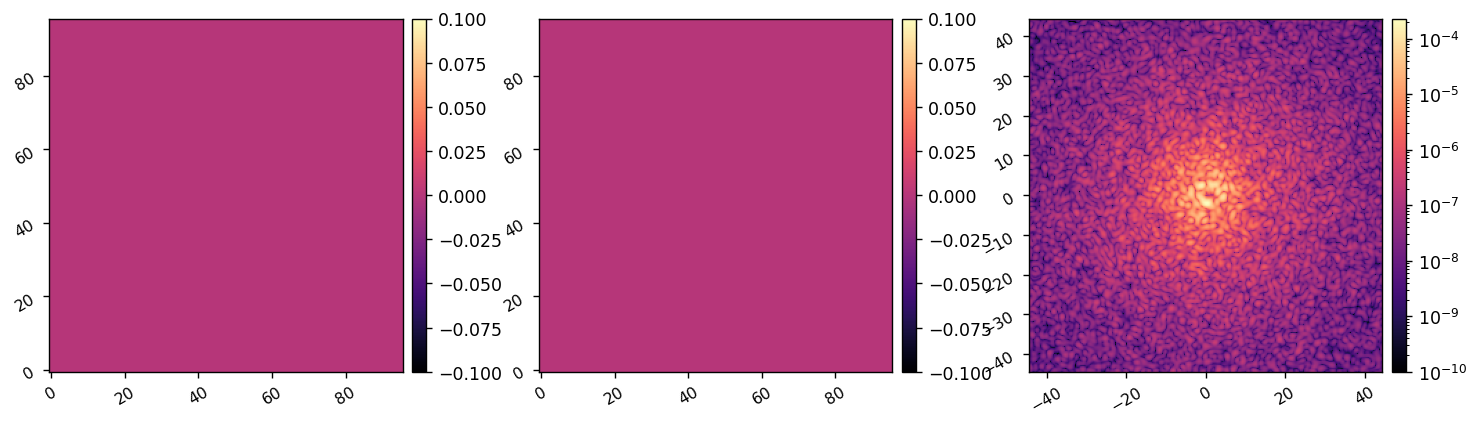

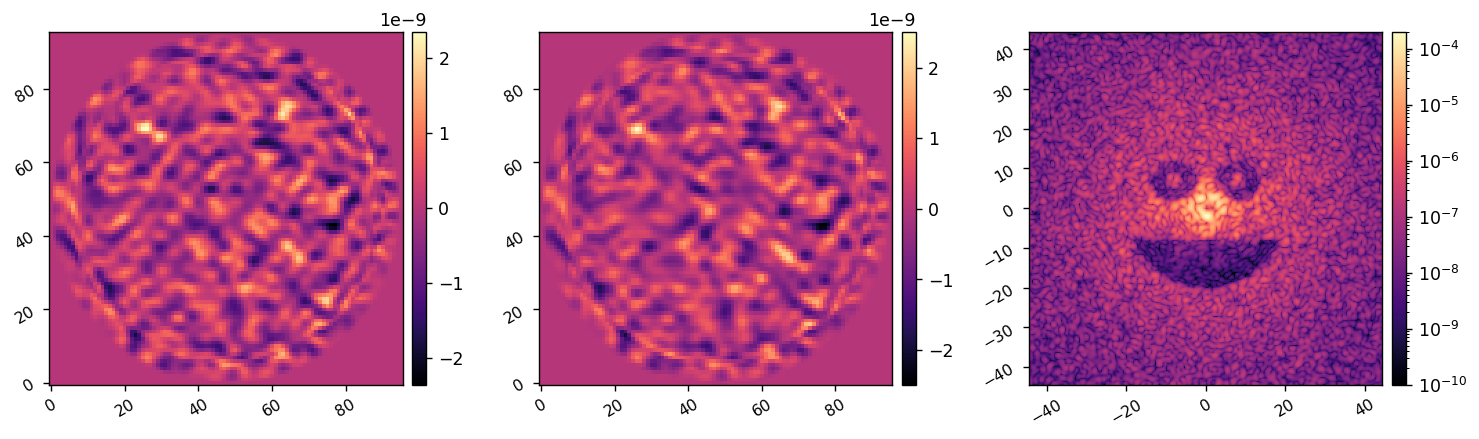

In [28]:
old_dm1 = fraunhofer.acts_to_command(current_acts[:M.Nacts//2], I.dm_mask)
old_dm2 = fraunhofer.acts_to_command(current_acts[M.Nacts//2:], I.dm_mask)
del_dm1 = fraunhofer.acts_to_command(res.x[:M.Nacts//2], I.dm_mask)
del_dm2 = fraunhofer.acts_to_command(res.x[M.Nacts//2:], I.dm_mask)

I.set_dm1(old_dm1)
I.set_dm2(old_dm2)
old_im = I.snap()

I.set_dm1(old_dm1 + del_dm1)
I.set_dm2(old_dm2 + del_dm2)
new_im = I.snap()

print(xp.mean(old_im[control_mask]), xp.mean(new_im[control_mask]))
imshow3(old_dm1, old_dm2, old_im, lognorm3=True, pxscl3=I.psf_pixelscale_lamDc, vmin3=1e-10,)
imshow3(del_dm1, del_dm2, new_im, lognorm3=True, pxscl3=I.psf_pixelscale_lamDc, vmin3=1e-10,)

In [18]:
utils.save_fits('ad_test_acts.fits', res.x)

Saved data to:  ad_test_acts.fits


In [40]:
I.zero_dms()
data = {
    # 'ref_im':ref_coro_im, 
    'images':[ref_coro_im],
    'efields':[],
    'dm1_commands':[],
    'del_dm1_commands':[],
    'dm2_commands':[],
    'del_dm2_commands':[],
    'reg_conds':[],
    'bfgs_tols':[],
    'pixelscale':I.psf_pixelscale_lamDc,
    'control_mask':control_mask, 
}

Computing E-field with model ...
Computing EFC command with L-BFGS
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =        14736     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.00000D+00    |proj g|=  2.37181D+06


 This problem is unconstrained.



At iterate    1    f=  9.84153D-01    |proj g|=  2.00376D+06

At iterate    2    f=  9.20309D-01    |proj g|=  9.35598D+05

At iterate    3    f=  9.05972D-01    |proj g|=  7.92177D+05

At iterate    4    f=  8.74752D-01    |proj g|=  8.57583D+05

At iterate    5    f=  8.60905D-01    |proj g|=  1.84507D+06

At iterate    6    f=  8.42786D-01    |proj g|=  7.70565D+05

At iterate    7    f=  8.26313D-01    |proj g|=  6.31980D+05

At iterate    8    f=  8.14238D-01    |proj g|=  7.27737D+05

At iterate    9    f=  7.89757D-01    |proj g|=  8.70995D+05

At iterate   10    f=  7.85594D-01    |proj g|=  1.83284D+06

At iterate   11    f=  7.67764D-01    |proj g|=  6.17439D+05

At iterate   12    f=  7.57852D-01    |proj g|=  6.22069D+05

At iterate   13    f=  7.45738D-01    |proj g|=  8.23264D+05

At iterate   14    f=  7.29035D-01    |proj g|=  8.87230D+05

At iterate   15    f=  7.27203D-01    |proj g|=  8.38904D+05

At iterate   16    f=  7.16542D-01    |proj g|=  5.11764D+05

At iter

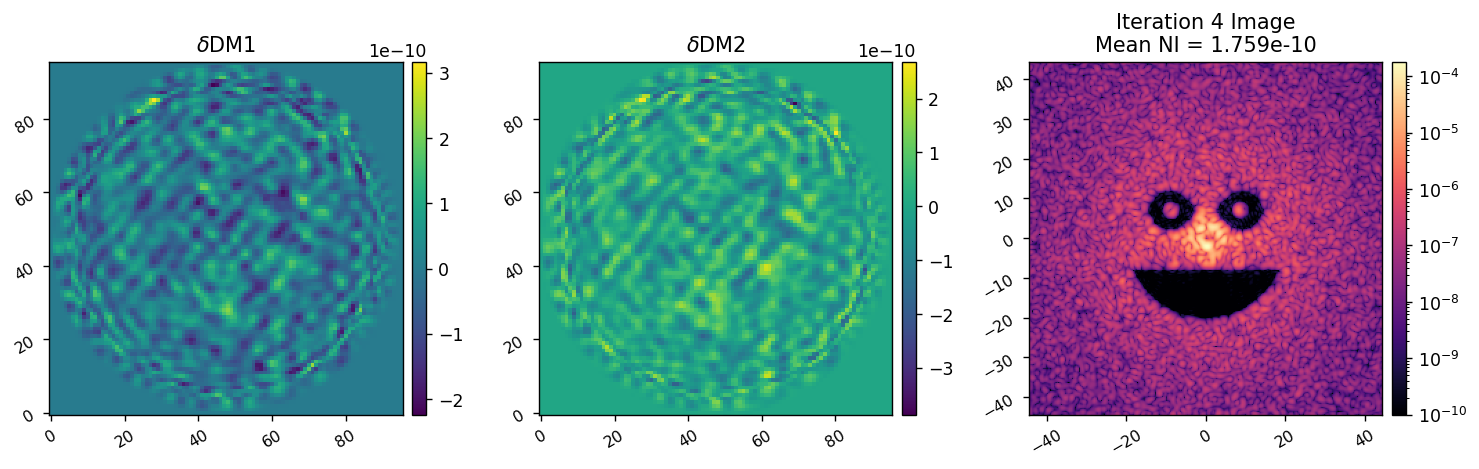

Computing E-field with model ...
Computing EFC command with L-BFGS
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =        14736     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.00000D+00    |proj g|=  2.22091D+06


 This problem is unconstrained.



At iterate    1    f=  9.92050D-01    |proj g|=  1.89155D+06

At iterate    2    f=  9.57766D-01    |proj g|=  8.06657D+05

At iterate    3    f=  9.47970D-01    |proj g|=  9.06913D+05

At iterate    4    f=  9.17972D-01    |proj g|=  1.15244D+06

At iterate    5    f=  9.14614D-01    |proj g|=  9.84745D+05

At iterate    6    f=  8.94321D-01    |proj g|=  8.15250D+05

At iterate    7    f=  8.81872D-01    |proj g|=  6.51311D+05

At iterate    8    f=  8.69761D-01    |proj g|=  1.91648D+06

At iterate    9    f=  8.55831D-01    |proj g|=  8.03737D+05

At iterate   10    f=  8.48160D-01    |proj g|=  6.55971D+05

At iterate   11    f=  8.31773D-01    |proj g|=  7.47404D+05

At iterate   12    f=  8.25791D-01    |proj g|=  8.13086D+05

At iterate   13    f=  8.18017D-01    |proj g|=  8.77558D+05

At iterate   14    f=  8.15721D-01    |proj g|=  2.49624D+06

At iterate   15    f=  8.03392D-01    |proj g|=  7.38736D+05

At iterate   16    f=  7.96098D-01    |proj g|=  6.54567D+05

At iter

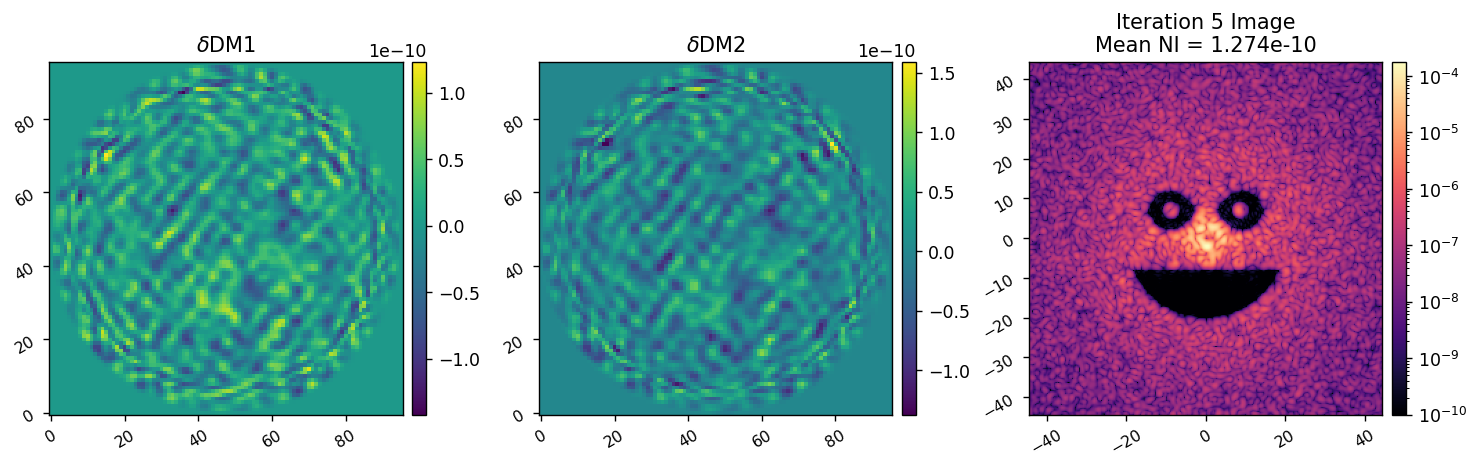

Computing E-field with model ...
Computing EFC command with L-BFGS
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =        14736     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.00000D+00    |proj g|=  1.50049D+06


 This problem is unconstrained.



At iterate    1    f=  9.97028D-01    |proj g|=  1.31891D+06

At iterate    2    f=  9.82648D-01    |proj g|=  8.99696D+05

At iterate    3    f=  9.76349D-01    |proj g|=  8.54682D+05

At iterate    4    f=  9.59057D-01    |proj g|=  1.40494D+06

At iterate    5    f=  9.55183D-01    |proj g|=  1.01548D+06

At iterate    6    f=  9.43294D-01    |proj g|=  7.75374D+05

At iterate    7    f=  9.34948D-01    |proj g|=  8.14684D+05

At iterate    8    f=  9.24361D-01    |proj g|=  1.55513D+06

At iterate    9    f=  9.15016D-01    |proj g|=  1.17186D+06

At iterate   10    f=  9.07272D-01    |proj g|=  7.17649D+05

At iterate   11    f=  8.94618D-01    |proj g|=  9.05285D+05

At iterate   12    f=  8.90294D-01    |proj g|=  1.62513D+06

At iterate   13    f=  8.83634D-01    |proj g|=  8.65815D+05

At iterate   14    f=  8.75816D-01    |proj g|=  7.53609D+05

At iterate   15    f=  8.72950D-01    |proj g|=  1.28961D+06

At iterate   16    f=  8.68125D-01    |proj g|=  9.64675D+05

At iter

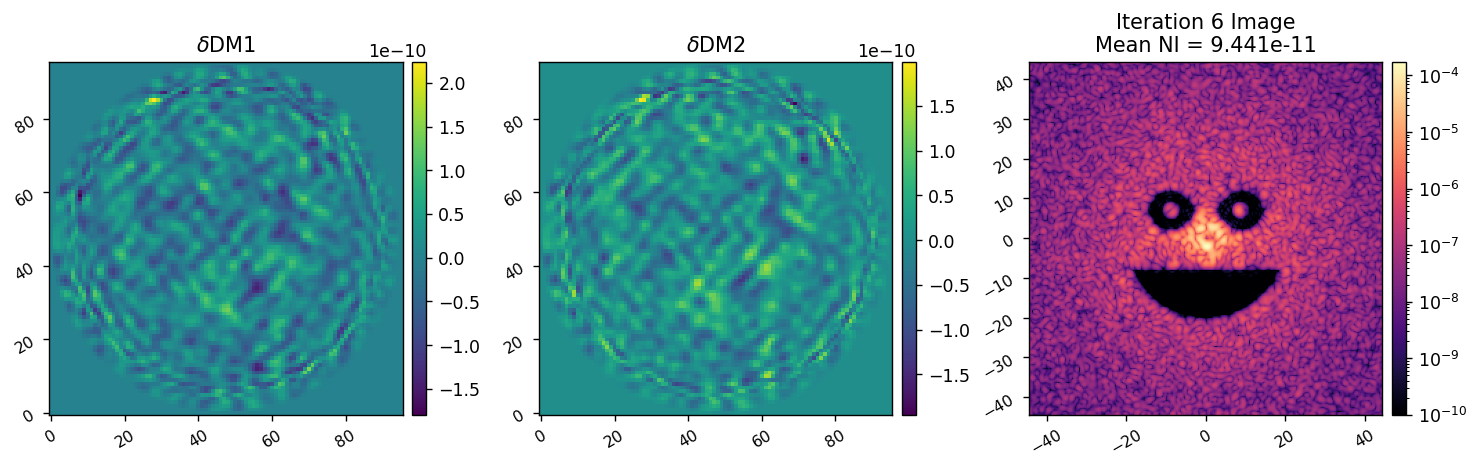

In [42]:
reload(fraunhofer)
reload(aefc)

r_cond = 1e-2
r_cond = 1e-3
# r_cond = 1e-4
# r_cond = 1e-5
# r_cond = 1e-6
# r_cond = 1e-7

bfgs_tol = 1e-2
bfgs_tol = 1e-3
# bfgs_tol = 1e-4
# bfgs_tol = 1e-5

bfgs_opts = {
    'disp':1,
    'maxiter':50,
    # 'ftol':1e-6,
    # 'gtol':1e-6,
}

data = aefc.run(
    I, 
    M, 
    fraunhofer.val_and_grad, 
    control_mask, 
    data,
    Nitr=3, 
    reg_cond=r_cond,
    bfgs_tol=bfgs_tol,
    bfgs_opts=bfgs_opts,
    gain=1,
)

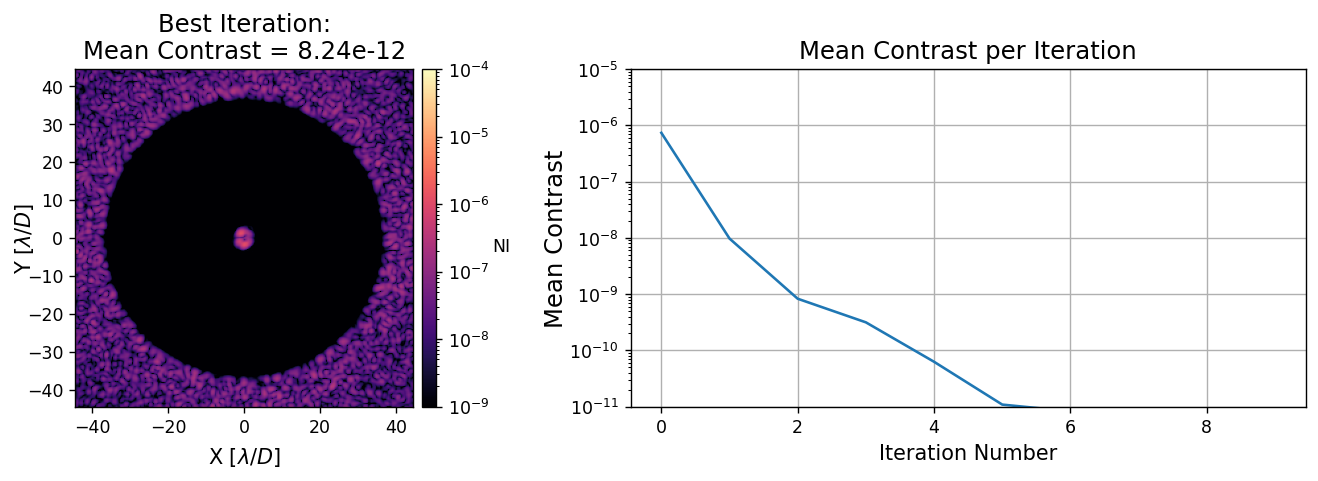

In [ ]:
plot_data(data, vmin=1e-11, vmax=1e-5)